# FedCircuitNet - DRC Violation Prediction Federated Experiments

This notebook shows the training and testing results of the federated learning runs orchestrated by `run_all_experiments.sh` (train + test pairs under `./config/`).

For each partitioning scheme (`iid`, `kmeans`, `dirichlet`, `feature_hierarchical`) we visualise:

1. **Training configuration** (strategy, model, optimizer, loss).
2. **Partition distribution** (per-client sample count and per-stratification-column histograms tracked at round 0 of `train_aim.py`).
3. **Training curves** (per-round mean client train loss, per-client loss traces, wall-clock timings) and optional validation metrics.
4. **Test results**: per-sample metric distributions (NRMS/SSIM), ROC curves, confusion matrices and a final aggregate table with ROC-AUC / TPR @ FPR=5% / accuracy.

Everything is read from the local Aim repository (`aim.Repo(path=os.getcwd())`).

## Setup and helpers

In [1]:
import os
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aim import Repo
from aim.storage.context import Context

# Aim repo lives at the FedCircuitNet root (same convention as the centralized
# example notebook code_examples/CircuitNet/drc_prediction/show_experiment_result.ipynb).
repo = Repo(path=os.getcwd())

# Train configs used in run_all_experiments.sh set the following `experiment`
# names in their yaml.  Some scheme yamls share the same experiment name, so
# we always disambiguate the run by its partitioning type (train) or by the
# checkpoint's parent directory (test).
TRAIN_EXPERIMENTS = [
    'fedavg_drc_train',
]

TEST_EXPERIMENTS = [
    'fedavg_drc_test',
]

# Presentation order for tables/plots.
SCHEME_ORDER = ['iid', 'kmeans', 'dirichlet', 'feature_hierarchical', 'feature_hierarchical_groupnorm', 'kmeans-groupnorm']

In [2]:
def get_runs_by_experiment_name(experiment_name):
    query = (
        'run.active == False and run.archived == False '
        f'and run.experiment == "{experiment_name}"'
    )
    return list(repo.query_runs(query=query, report_mode=0).iter_runs())


def collect_runs(experiment_names):
    """Flatten runs across a list of experiment names, deduped by hash."""
    seen = set()
    runs = []
    for name in experiment_names:
        for wrapper in get_runs_by_experiment_name(name):
            r = wrapper.run
            if r.hash in seen:
                continue
            seen.add(r.hash)
            runs.append(r)
    return runs


def train_scheme_tag(run):
    """Return a stable label (partitioning type) for a train run."""
    hparams = run.get('hparams') or {}
    partitioning = hparams.get('partitioning') or {}
    model = hparams.get('model') or {}
    return f"{partitioning.get('type') or (run.experiment or run.hash)}_{model.get('type') or 'Routenet'}"


def test_scheme_tag(run):
    """Return a stable label for a test run based on the checkpoint dir.
    
    Test yamls store `checkpoint: ./work_dirs/fedavg_<scheme>/global_model_final.pth`,
    so the parent dir gives us the scheme.
    """
    hparams = run.get('hparams') or {}
    checkpoint = hparams.get('checkpoint') or ''
    model = hparams.get('model') or {}
    parent = os.path.basename(os.path.dirname(checkpoint)) if checkpoint else ''
    if parent.startswith('fedavg_'):
        return parent[len('fedavg_'):]
    return parent or run.hash


def sort_by_scheme(runs, tag_fn):
    order = {name: i for i, name in enumerate(SCHEME_ORDER)}
    return sorted(runs, key=lambda r: order.get(tag_fn(r), len(order)))


def metric_values_sorted(run, name, context=None):
    """Return the metric's values in ascending timestamp order (empty if missing)."""
    metric = run.get_metric(name, context=Context(context or {}))
    if metric is None:
        return np.array([])
    ts = metric.timestamps.values_numpy()
    vals = metric.values.values_numpy()
    return vals[np.argsort(ts)]


def metric_series_with_steps(run, name, context=None):
    """Return (steps, values) sorted by step for the given metric."""
    metric = run.get_metric(name, context=Context(context or {}))
    if metric is None:
        return np.array([]), np.array([])

    steps = metric.timestamps.values_numpy()
    vals = metric.values.values_numpy()
    idx = np.argsort(steps)
    return steps[idx], vals[idx]


def get_hist_data_for_distribution(run, name, context=None):
    """Fetch the last-tracked histogram counts stored under `name`.
    
    In `train_aim.py`, partition histograms are pushed as
    `Distribution.from_histogram(counts, (0, K))`, so the histogram bins are
    the client indices and the counts are the client sample counts (or the
    per-value counts for `partitions/<col>`).
    """
    sequences_info = run.collect_sequence_info(sequence_types=['distributions'])
    for dist_info in sequences_info.get('distributions', []):
        if dist_info['name'] != name:
            continue
        if context is not None and dist_info.get('context') != context:
            continue
        last = dist_info['values']['last']
        return last.to_np_histogram()
    return None

## Train configurations

Summary of the hyper-parameters recorded in the Aim `hparams` of each train run.

In [3]:
train_runs = sort_by_scheme(collect_runs(TRAIN_EXPERIMENTS), train_scheme_tag)

train_conf_rows = []
for run in train_runs:
    hparams = run.get('hparams') or {}
    partitioning = hparams.get('partitioning') or {}
    strategy = hparams.get('strategy') or {}
    model = hparams.get('model') or {}
    training = hparams.get('training') or {}
    evaluation = hparams.get('evaluation') or {}

    train_conf_rows.append({
        'tag': train_scheme_tag(run),
        'experiment': run.experiment,
        'partitioning': partitioning.get('type'),
        'n_partitions': partitioning.get('n_partitions'),
        'partition_features': partitioning.get('features'),
        'strategy': strategy.get('type'),
        'model': model.get('type'),
        'in/out_ch': f"{model.get('in_channels')}/{model.get('out_channels')}",
        'local_epochs': strategy.get('local_epochs'),
        'batch_size': strategy.get('batch_size'),
        'lr': strategy.get('learning_rate'),
        'loss': strategy.get('loss_type'),
        'eval_metric': strategy.get('eval_metric'),
        'num_rounds': training.get('num_rounds'),
        'val_threshold': evaluation.get('threshold'),
    })

train_conf_df = pd.DataFrame(train_conf_rows)
display(train_conf_df)

,tag,experiment,partitioning,n_partitions,partition_features,strategy,model,in/out_ch,local_epochs,batch_size,lr,loss,eval_metric,num_rounds,val_threshold
0,dirichlet_RouteNetGroupNorm,fedavg_drc_train,dirichlet,20,"[design_name, clock, utilization]",fedavg,RouteNetGroupNorm,9/1,20,8,0.0002,BiasedMSELoss,"[NRMS, SSIM]",200,0.1
1,iid_RouteNetGroupNorm,fedavg_drc_train,iid,20,None,fedavg,RouteNetGroupNorm,9/1,20,8,0.0002,BiasedMSELoss,"[NRMS, SSIM]",200,0.1
2,feature_hierarchical_RouteNetGroupNorm,fedavg_drc_train,feature_hierarchical,20,"[design_name, clock, utilization]",fedavg,RouteNetGroupNorm,9/1,20,8,0.0002,BiasedMSELoss,"[NRMS, SSIM]",200,0.1
3,kmeans_RouteNetGroupNorm,fedavg_drc_train,kmeans,20,None,fedavg,RouteNetGroupNorm,9/1,20,8,0.0002,BiasedMSELoss,"[NRMS, SSIM]",200,0.1
4,feature_hierarchical_RouteNet,fedavg_drc_train,feature_hierarchical,20,"[design_name, clock, utilization]",fedavg,RouteNet,9/1,20,8,0.0002,BiasedMSELoss,"[NRMS, SSIM]",200,0.1
5,dirichlet_RouteNet,fedavg_drc_train,dirichlet,20,"[design_name, clock, utilization]",fedavg,RouteNet,9/1,20,8,0.0002,BiasedMSELoss,"[NRMS, SSIM]",200,0.1
6,kmeans_RouteNet,fedavg_drc_train,kmeans,20,None,fedavg,RouteNet,9/1,20,8,0.0002,BiasedMSELoss,"[NRMS, SSIM]",200,0.1
7,iid_RouteNet,fedavg_drc_train,iid,20,None,fedavg,RouteNet,9/1,20,8,0.0002,BiasedMSELoss,"[NRMS, SSIM]",200,0.1


## Partition distribution per run

For every run, we plot:

* the per-client sample count bar chart (tracked as the `partitions` distribution at round 0),
* for every stratification column that the partitioner declares (e.g. `design_name`, `clock`, `utilization`, ...), the per-client stacked distribution of that column's values (from the `partitions/<col>` distributions).

The IID partitioner tracks a flat set of columns from the metadata; K-means / dirichlet / feature_hierarchical use the columns from their `features` field.

In [4]:
def plot_partition_sizes(ax, counts, tag):
    x = np.arange(len(counts))
    ax.bar(x, counts, edgecolor='black', alpha=0.75)
    ax.set_title(f'Partition sizes - {tag}')
    ax.set_xlabel('Client ID')
    ax.set_ylabel('# samples')
    ax.set_xticks(x)
    for i, v in enumerate(counts):
        ax.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=8)


def plot_column_stacked(ax, per_client_counts, col_name):
    per_client_counts = np.asarray(per_client_counts, dtype=float)
    if per_client_counts.ndim != 2 or per_client_counts.size == 0:
        ax.set_visible(False)
        return
    n_clients, n_vals = per_client_counts.shape
    x = np.arange(n_clients)
    bottom = np.zeros(n_clients)
    cmap = plt.get_cmap('tab20', max(n_vals, 1))
    for v in range(n_vals):
        ax.bar(x, per_client_counts[:, v], bottom=bottom, color=cmap(v),
               edgecolor='black', linewidth=0.3, label=f'val {v}')
        bottom += per_client_counts[:, v]
    ax.set_title(f'Distribution of `{col_name}` per client')
    ax.set_xlabel('Client ID')
    ax.set_ylabel('# samples')
    ax.set_xticks(x)
    if n_vals <= 12:
        ax.legend(fontsize=7, ncol=min(n_vals, 4))


def collect_per_column_counts(run):
    """Group `partitions/<col>` distributions by column name and stack them
    into a (n_clients, n_values) matrix ordered by partition_id."""
    seq_info = run.collect_sequence_info(sequence_types=['distributions'])
    per_col = defaultdict(dict)
    for dist_info in seq_info.get('distributions', []):
        name = dist_info.get('name', '')
        if not name.startswith('partitions/'):
            continue
        col = name.split('/', 1)[1]
        ctx = dist_info.get('context') or {}
        pid = ctx.get('partition_id')
        if pid is None:
            continue
        counts, _ = dist_info['values']['last'].to_np_histogram()
        per_col[col][int(pid)] = np.asarray(counts, dtype=float)

    out = {}
    for col, pid_map in per_col.items():
        ordered_pids = sorted(pid_map.keys())
        rows = [pid_map[p] for p in ordered_pids]
        width = max(len(r) for r in rows)
        padded = np.array([np.pad(r, (0, width - len(r))) for r in rows])
        out[col] = padded
    return out


for run in train_runs:
    tag = train_scheme_tag(run)
    partition_hist = get_hist_data_for_distribution(run, 'partitions')
    if partition_hist is None:
        print(f'[{tag}] no partition distribution found - skipping')
        continue
    partition_counts, _ = partition_hist
    per_col = collect_per_column_counts(run)

    n_cols = 1 + len(per_col)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]
    plot_partition_sizes(axes[0], np.asarray(partition_counts), tag)
    for ax, (col, matrix) in zip(axes[1:], per_col.items()):
        plot_column_stacked(ax, matrix, col)
    fig.suptitle(f'Run: {tag}')
    plt.show()
    plt.close(fig)

<Figure size 2000x400 with 4 Axes>

<Figure size 2000x400 with 4 Axes>

<Figure size 2000x400 with 4 Axes>

<Figure size 4000x400 with 8 Axes>

<Figure size 2000x400 with 4 Axes>

<Figure size 2000x400 with 4 Axes>

<Figure size 4000x400 with 8 Axes>

<Figure size 2000x400 with 4 Axes>

## Training curves

Two plots per run:

* **Mean client train loss** per FL round (averaged across selected clients each round).
* **Per-client train loss** trajectories - one line per client. Traces are indexed by round (steps recorded through `on_round_end`).

The Aim scalars are the ones pushed inside `_build_round_callback` of `train_aim.py`.

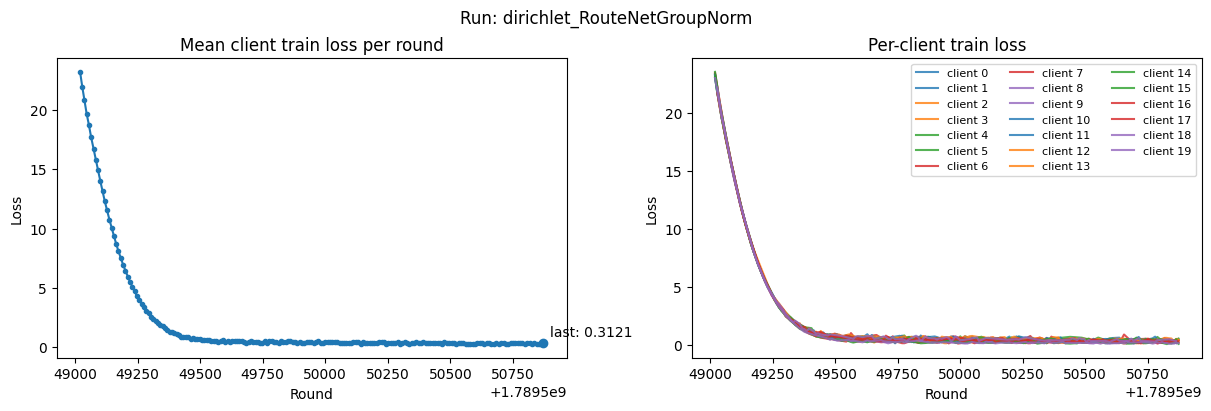

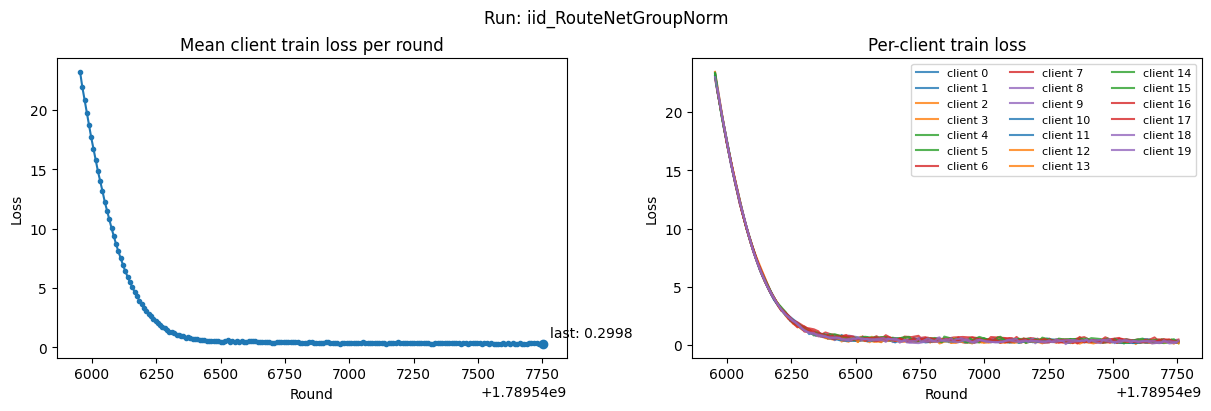

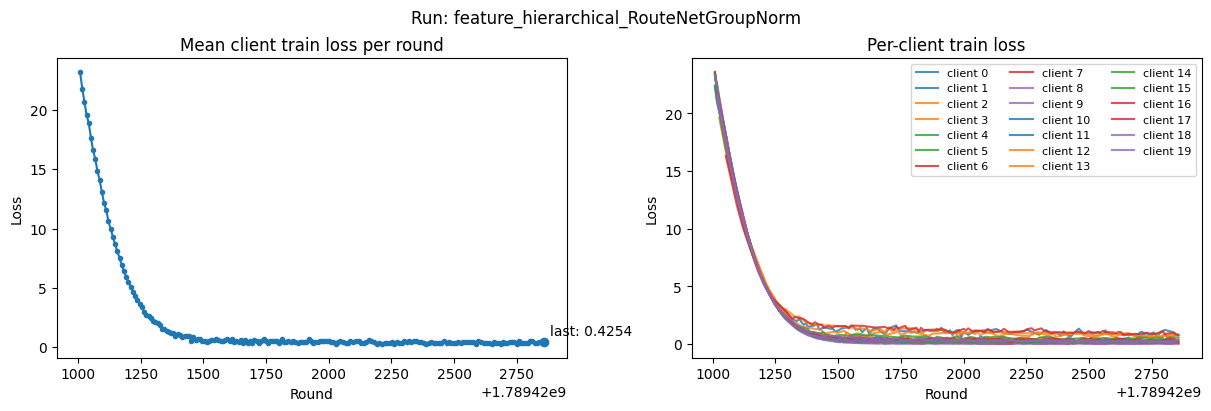

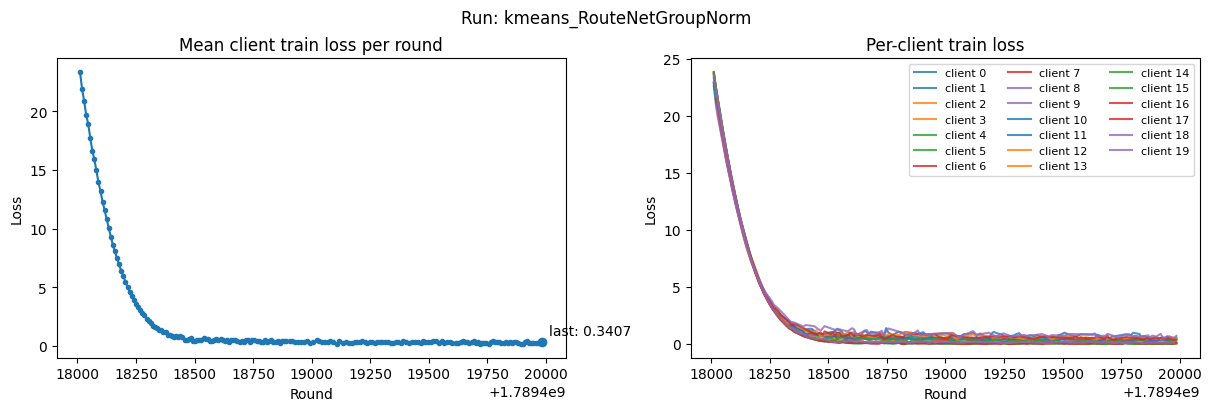

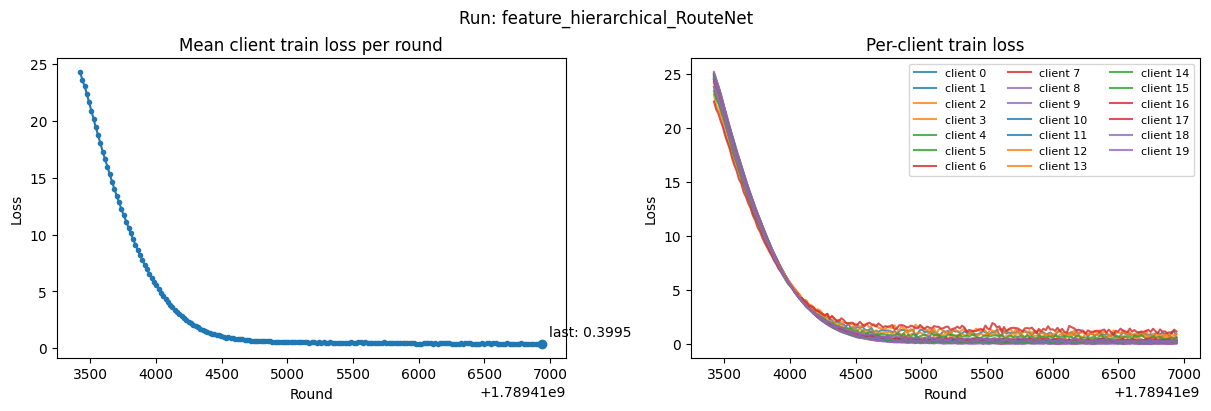

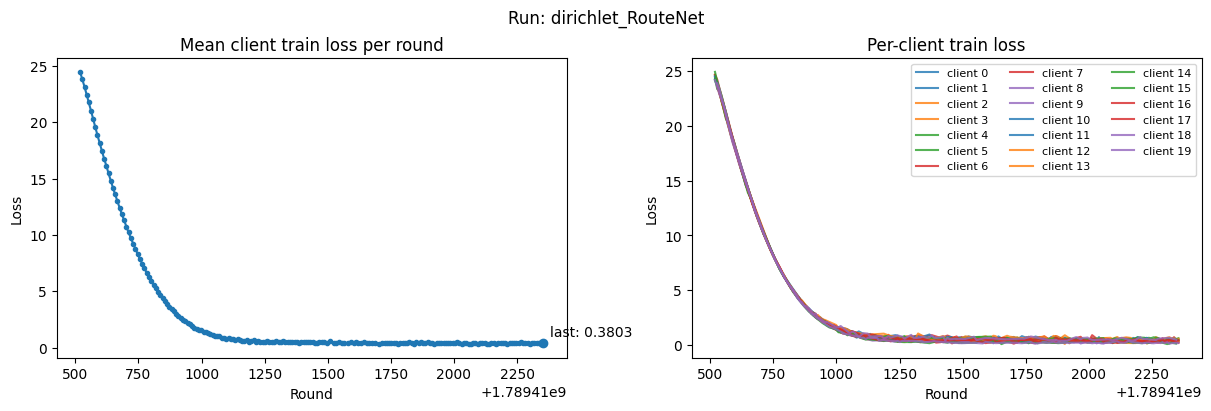

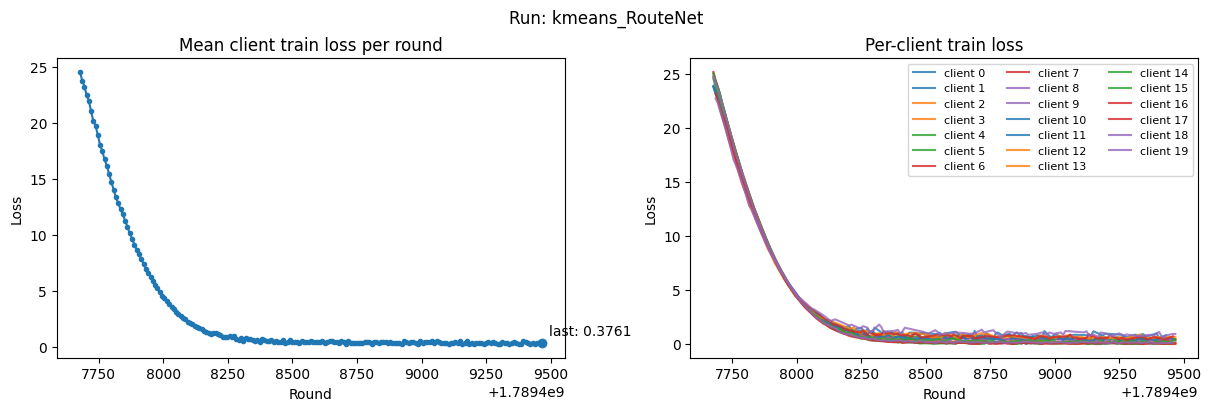

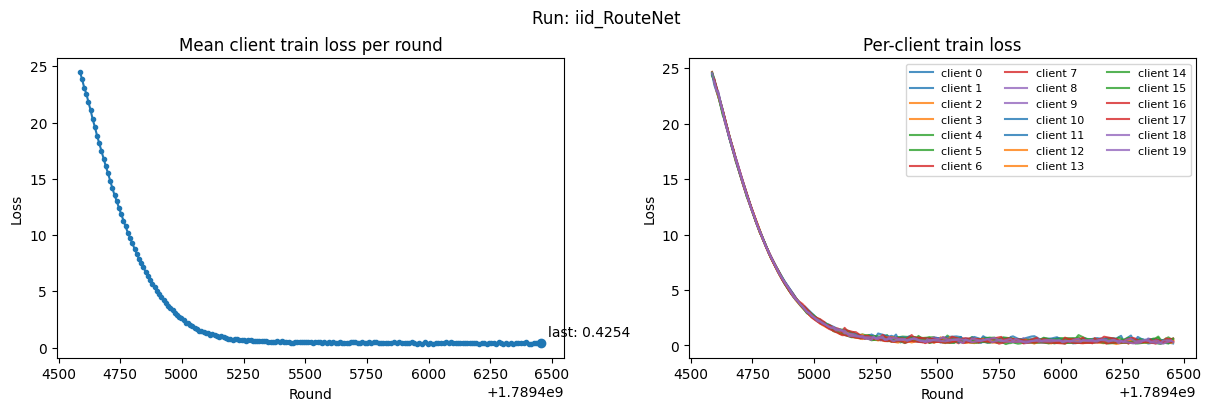

,tag,final_mean_client_loss,num_rounds_recorded,num_clients
0,dirichlet_RouteNetGroupNorm,0.312148,200,20
1,iid_RouteNetGroupNorm,0.299813,200,20
2,feature_hierarchical_RouteNetGroupNorm,0.425416,200,20
3,kmeans_RouteNetGroupNorm,0.340716,200,20
4,feature_hierarchical_RouteNet,0.399518,200,20
5,dirichlet_RouteNet,0.380335,200,20
6,kmeans_RouteNet,0.376094,200,20
7,iid_RouteNet,0.425363,200,20


In [5]:
def collect_per_client_losses(run):
    """Return {client_id: (steps_sorted, values_sorted)} for `Client Train Loss`."""
    seq_info = run.collect_sequence_info(sequence_types=['metric'])
    out = {}
    for m in seq_info.get('metric', []):
        if m.get('name') != 'Client Train Loss':
            continue
        ctx = m.get('context') or {}
        cid = ctx.get('client_id')
        if cid is None:
            continue
        steps, vals = metric_series_with_steps(run, 'Client Train Loss', context=ctx)
        if steps.size:
            out[int(cid)] = (steps, vals)
    return out


loss_summary_rows = []
for run in train_runs:
    tag = train_scheme_tag(run)

    mean_steps, mean_vals = metric_series_with_steps(
        run, 'Mean Client Train Loss', context={'subset': 'train'}
    )
    per_client = collect_per_client_losses(run)

    if mean_vals.size == 0 and not per_client:
        print(f'[{tag}] no train-loss metrics found - skipping')
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    fig.suptitle(f'Run: {tag}')

    if mean_vals.size:
        axes[0].plot(mean_steps, mean_vals, marker='o', markersize=3)
        axes[0].set_title('Mean client train loss per round')
        axes[0].set_xlabel('Round')
        axes[0].set_ylabel('Loss')
        last_v = float(mean_vals[-1])
        last_s = int(mean_steps[-1])
        axes[0].scatter([last_s], [last_v])
        axes[0].annotate(f'last: {last_v:.4f}', (last_s, last_v),
                         textcoords='offset points', xytext=(5, 5))
    else:
        axes[0].set_visible(False)
        last_v = float('nan')

    if per_client:
        cmap = plt.get_cmap('tab10', max(len(per_client), 1))
        for i, (cid, (steps, vals)) in enumerate(sorted(per_client.items())):
            axes[1].plot(steps, vals, color=cmap(i % 10), alpha=0.8,
                         label=f'client {cid}')
        axes[1].set_title('Per-client train loss')
        axes[1].set_xlabel('Round')
        axes[1].set_ylabel('Loss')
        axes[1].legend(fontsize=8, ncol=min(len(per_client), 3))
    else:
        axes[1].set_visible(False)

    plt.show()
    plt.close(fig)

    loss_summary_rows.append({
        'tag': tag,
        'final_mean_client_loss': last_v,
        'num_rounds_recorded': int(mean_steps.size),
        'num_clients': len(per_client),
    })

display(pd.DataFrame(loss_summary_rows))

## Test configurations

In [6]:
test_runs = sort_by_scheme(collect_runs(TEST_EXPERIMENTS), test_scheme_tag)

test_conf_rows = []
for run in test_runs:
    hparams = run.get('hparams') or {}
    model = hparams.get('model') or {}
    evaluation = hparams.get('evaluation') or {}
    test_conf_rows.append({
        'tag': test_scheme_tag(run),
        'experiment': run.experiment,
        'checkpoint': hparams.get('checkpoint'),
        'model': model.get('type'),
        'in/out_ch': f"{model.get('in_channels')}/{model.get('out_channels')}",
        'eval_metric': evaluation.get('eval_metric'),
        'threshold': evaluation.get('threshold'),
        'plot_roc': evaluation.get('plot_roc'),
    })

test_conf_df = pd.DataFrame(test_conf_rows)
display(test_conf_df)

,tag,experiment,checkpoint,model,in/out_ch,eval_metric,threshold,plot_roc
0,iid,fedavg_drc_test,./work_dirs/fedavg_iid/model_round_0200.pth,RouteNet,9/1,"[NRMS, SSIM]",0.1,True
1,kmeans,fedavg_drc_test,./work_dirs/fedavg_kmeans/model_round_0200.pth,RouteNet,9/1,"[NRMS, SSIM]",0.1,True
2,dirichlet,fedavg_drc_test,./work_dirs/fedavg_dirichlet/model_round_0200.pth,RouteNet,9/1,"[NRMS, SSIM]",0.1,True
3,feature_hierarchical,fedavg_drc_test,./work_dirs/fedavg_feature_hierarchical/model_...,RouteNet,9/1,"[NRMS, SSIM]",0.1,True
4,feature_hierarchical_groupnorm,fedavg_drc_test,./work_dirs/fedavg_feature_hierarchical_groupn...,RouteNetGroupNorm,9/1,"[NRMS, SSIM]",0.1,True
5,dirichlet_gn,fedavg_drc_test,./work_dirs/fedavg_dirichlet_gn/model_round_02...,RouteNetGroupNorm,9/1,"[NRMS, SSIM]",0.1,True
6,iid_gn,fedavg_drc_test,./work_dirs/fedavg_iid_gn/model_round_0200.pth,RouteNetGroupNorm,9/1,"[NRMS, SSIM]",0.1,True
7,kmeans_groupnorm,fedavg_drc_test,./work_dirs/fedavg_kmeans_groupnorm/model_roun...,RouteNetGroupNorm,9/1,"[NRMS, SSIM]",0.1,True


## Test metric distributions

Per-sample `Test NRMS (dist)` / `Test SSIM (dist)` values tracked by `test_aim.py`, shown as histograms with mean / std annotations.

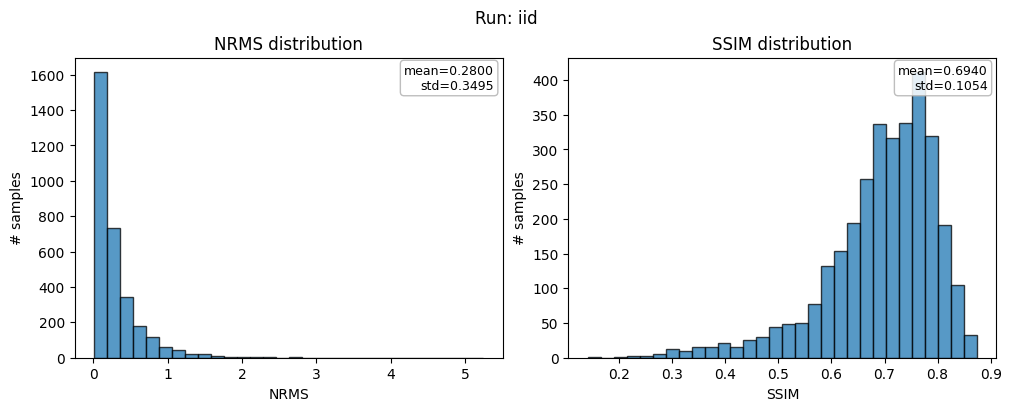

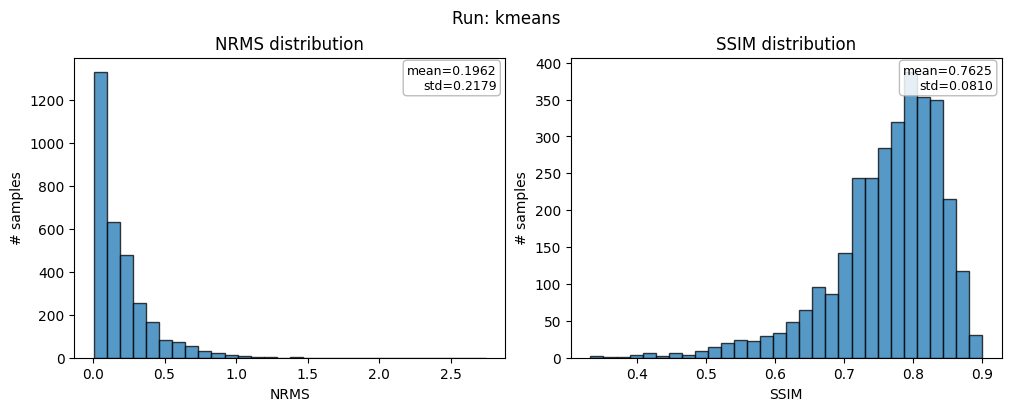

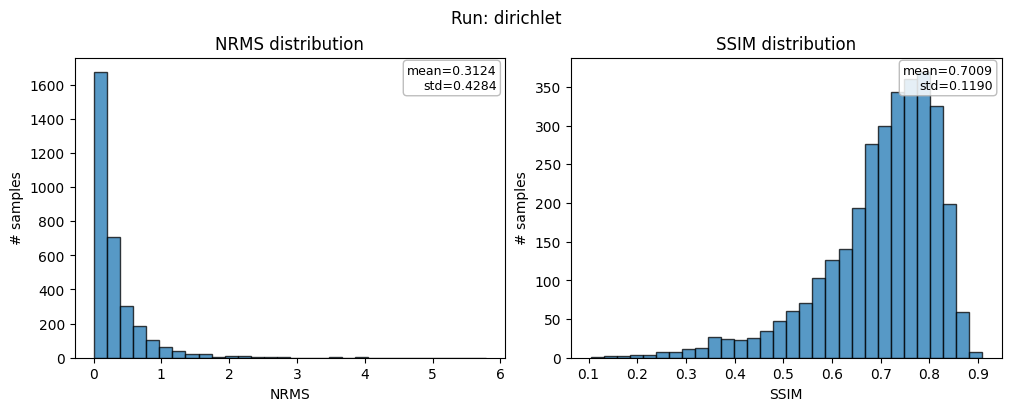

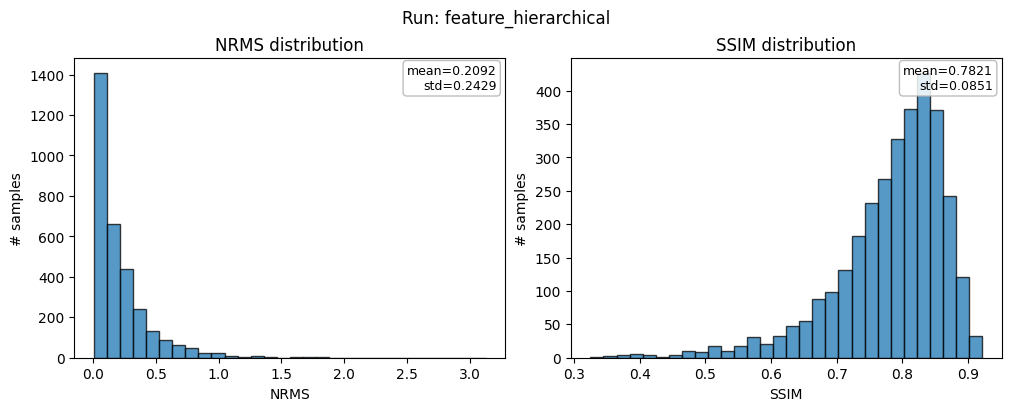

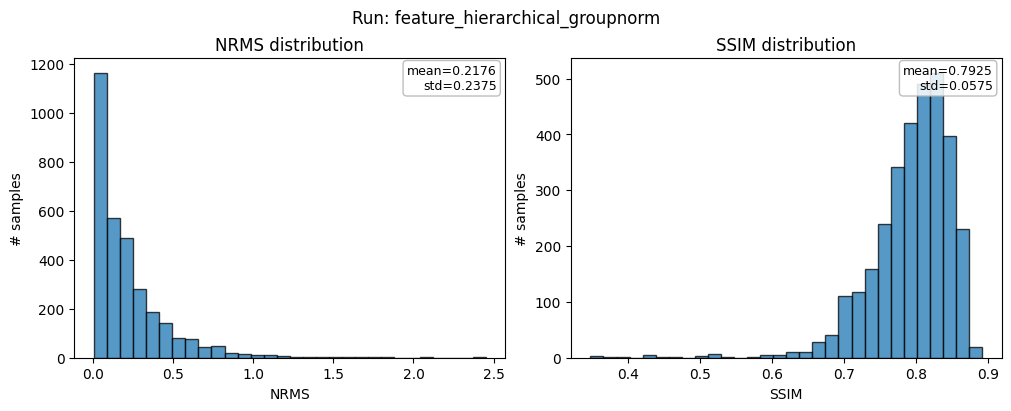

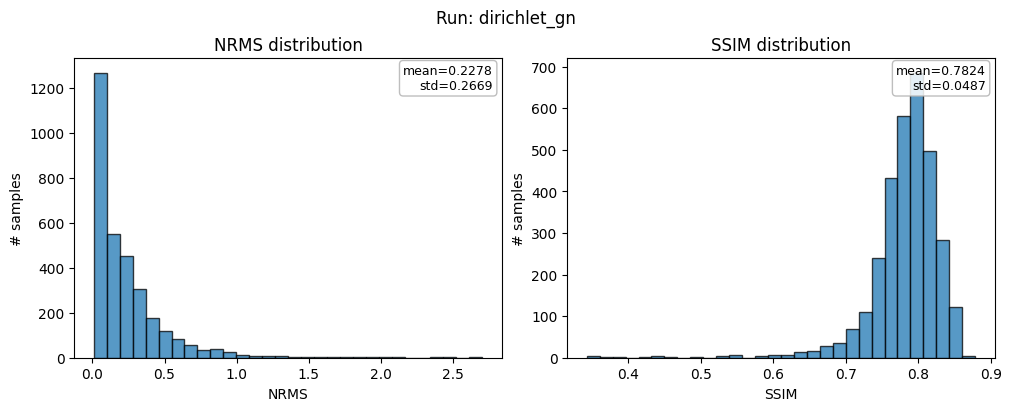

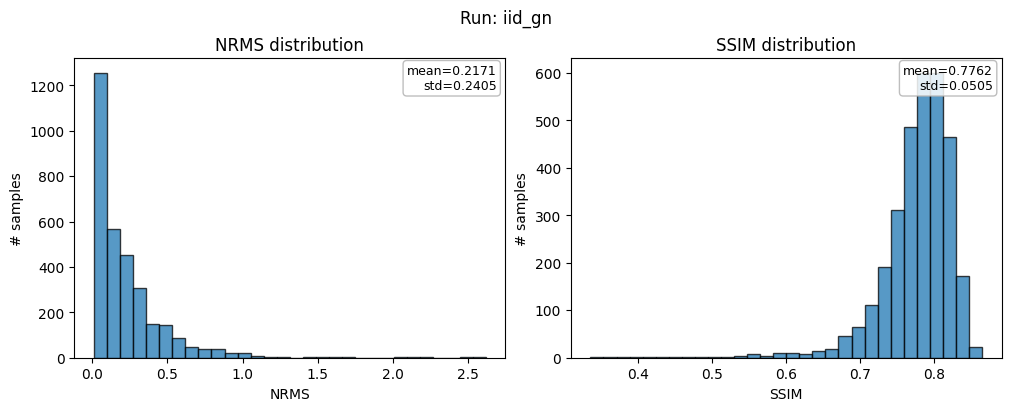

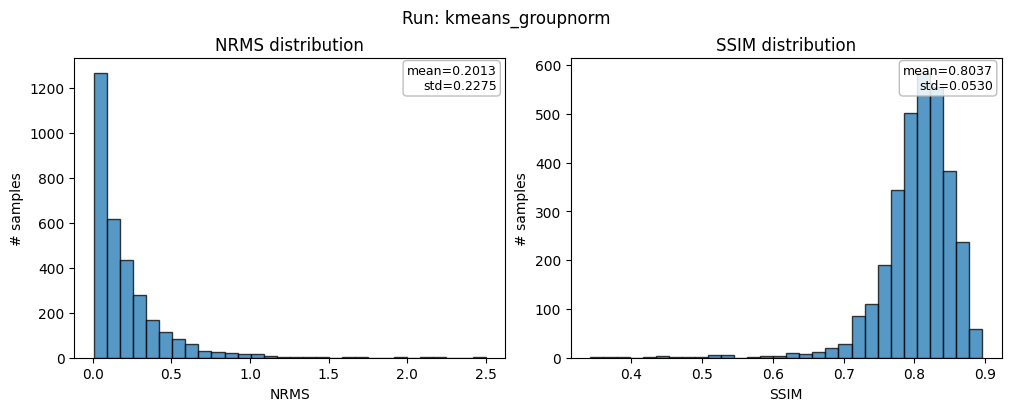

In [7]:
def per_sample_metric(run, metric_name):
    metric = run.get_metric(
        metric_name,
        context=Context({'subset': 'test', 'aggregation': 'distribution'}),
    )
    return metric.values.values_numpy() if metric is not None else np.array([])


for run in test_runs:
    tag = test_scheme_tag(run)
    hparams = run.get('hparams') or {}
    eval_metric = list((hparams.get('evaluation') or {}).get('eval_metric') or ['NRMS', 'SSIM'])

    values = {m: per_sample_metric(run, f'Test {m} (dist)') for m in eval_metric}
    values = {m: v for m, v in values.items() if v.size}
    if not values:
        print(f'[{tag}] no per-sample test distributions found - skipping')
        continue

    n = len(values)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), constrained_layout=True, squeeze=False)
    fig.suptitle(f'Run: {tag}')
    for ax, (m, vals) in zip(axes[0], values.items()):
        ax.hist(vals, bins=30, edgecolor='black', alpha=0.75)
        ax.set_title(f'{m} distribution')
        ax.set_xlabel(m)
        ax.set_ylabel('# samples')
        ax.text(0.98, 0.98,
                f'mean={np.mean(vals):.4f}\nstd={np.std(vals):.4f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85,
                          edgecolor='0.7'))
    plt.show()
    plt.close(fig)

## Test ROC curves

One overlay figure: FPR/TPR curves recorded by `test_aim.py` when `evaluation.plot_roc: true`. Area under the curve is computed with the trapezoidal rule from the same points, mirroring the centralized reference notebook.

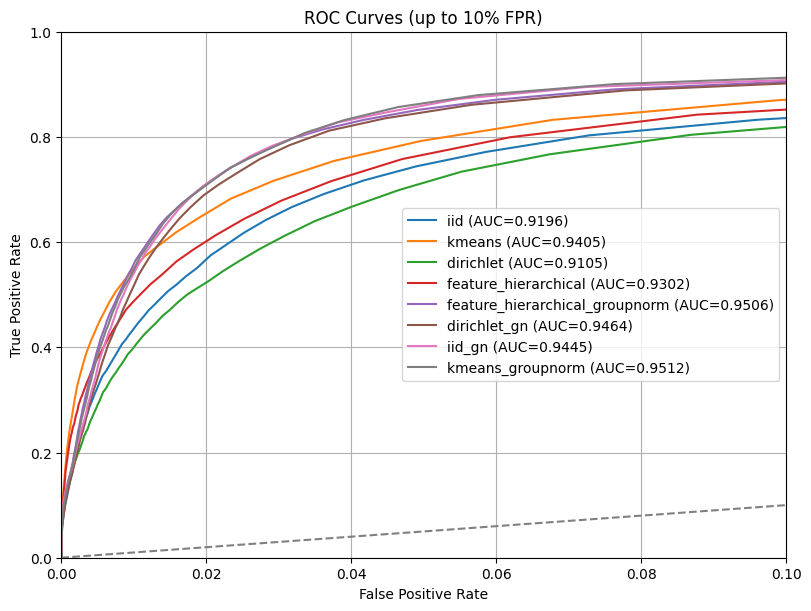

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def roc_curve(run):
    tpr = metric_values_sorted(run, 'ROC_TPR', context={'type': 'curve'})
    fpr = metric_values_sorted(run, 'ROC_FPR', context={'type': 'curve'})
    return fpr, tpr


fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
any_curve = False
max_fpr = 0.10

for run in test_runs:
    tag = test_scheme_tag(run)
    fpr, tpr = roc_curve(run)

    if fpr.size == 0 or tpr.size == 0:
        continue

    # Sort by FPR and remove duplicate values
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]

    fpr_unique, idx = np.unique(fpr, return_index=True)
    tpr_unique = tpr[idx]

    # Full AUC
    area = np.trapz(tpr_unique, fpr_unique)

    # Keep all points up to 10% FPR
    mask = fpr_unique <= max_fpr
    fpr_plot = fpr_unique[mask]
    tpr_plot = tpr_unique[mask]

    # Add the interpolated point at exactly 10% FPR
    if fpr_unique[-1] >= max_fpr:
        tpr_at_max = np.interp(
            max_fpr,
            fpr_unique,
            tpr_unique
        )

        # Avoid duplicate point if FPR is already exactly 0.10
        if fpr_plot.size == 0 or fpr_plot[-1] < max_fpr:
            fpr_plot = np.append(fpr_plot, max_fpr)
            tpr_plot = np.append(tpr_plot, tpr_at_max)

    if fpr_plot.size < 2:
        continue

    ax.plot(
        fpr_plot,
        tpr_plot,
        label=f'{tag} (AUC={area:.4f})'
    )
    any_curve = True

# Random classifier reference, ending at 10% FPR
ax.plot([0, max_fpr], [0, max_fpr], linestyle='--', color='gray')

ax.set_title('ROC Curves (up to 10% FPR)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim(0, max_fpr)
ax.set_ylim(0, 1)

if any_curve:
    ax.legend()

ax.grid(True)
plt.show()
plt.close(fig)

## Confusion matrices

One 2x2 confusion matrix per test run, built from `Confusion TP/TN/FP/FN` (summed over all test labels, binarised at the run's `evaluation.threshold`).

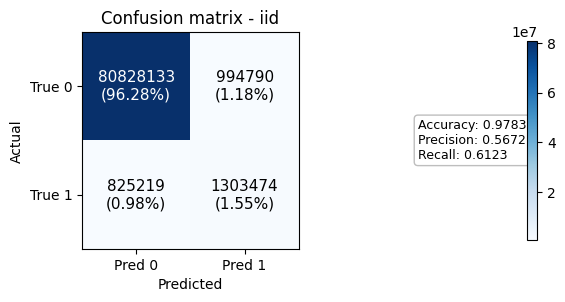

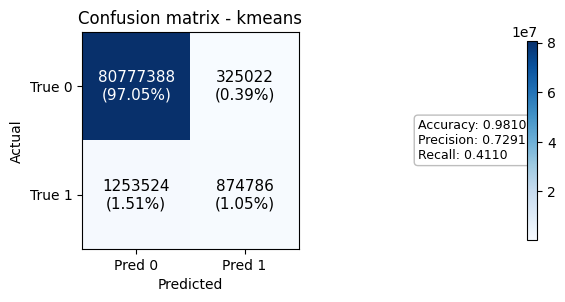

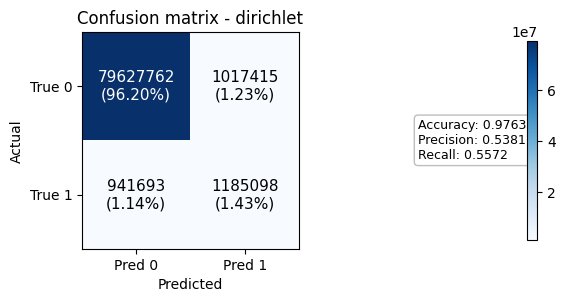

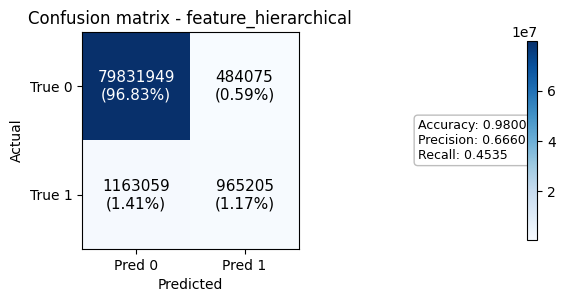

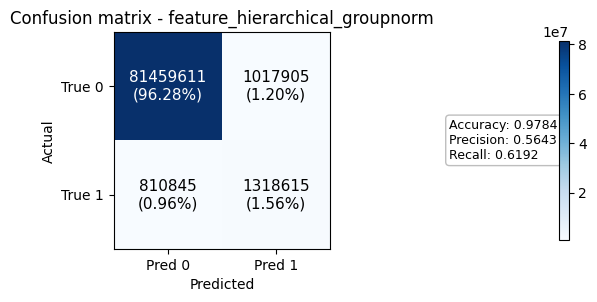

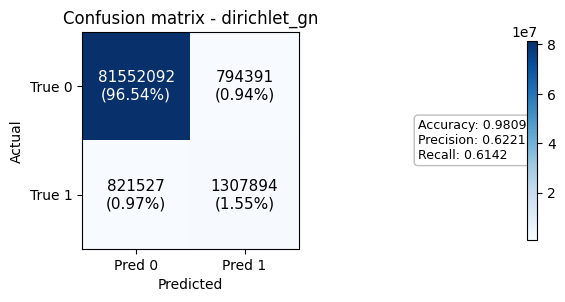

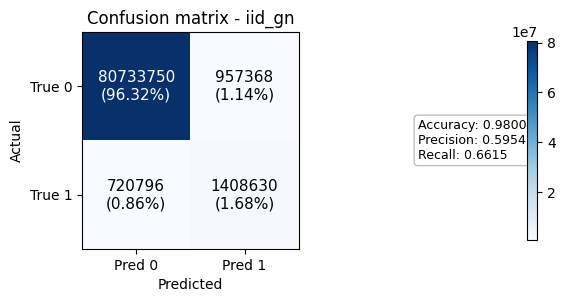

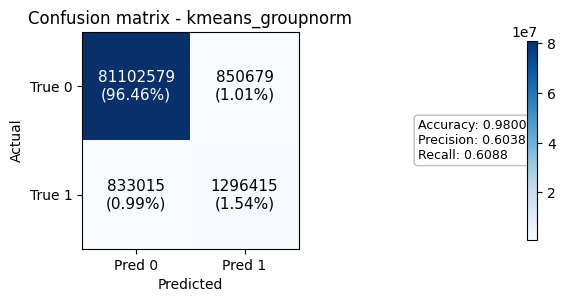

In [9]:
def cm_value(run, name):
    metric = run.get_metric(name, context=Context({'subset': 'test'}))
    return int(metric.values.values_numpy()[0]) if metric is not None else None


for run in test_runs:
    tag = test_scheme_tag(run)
    tn = cm_value(run, 'Confusion TN')
    fp = cm_value(run, 'Confusion FP')
    fn = cm_value(run, 'Confusion FN')
    tp = cm_value(run, 'Confusion TP')
    if None in (tn, fp, fn, tp):
        print(f'[{tag}] confusion counts not tracked - skipping')
        continue

    cm = np.array([[tn, fp], [fn, tp]])
    total = int(cm.sum())

    fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5), constrained_layout=True)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion matrix - {tag}')

    for i in range(2):
        for j in range(2):
            v = int(cm[i, j])
            pct = 100.0 * v / total if total else 0.0
            ax.text(j, i, f'{v}\n({pct:.2f}%)', ha='center', va='center',
                    color='white' if v > cm.max() / 2 else 'black', fontsize=11)

    if total:
        acc = (tn + tp) / total
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec = tp / (tp + fn) if (tp + fn) else 0.0
        ax.text(1.55, 0.5,
                f'Accuracy: {acc:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}',
                transform=ax.transAxes, va='center', ha='left', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85,
                          edgecolor='0.7'))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()
    plt.close(fig)

## Final aggregate results

One row per test run, combining:

* mean of the per-sample `Test NRMS (dist)` / `Test SSIM (dist)` values,
* trapezoidal AUC computed over the tracked ROC curve points,
* TPR interpolated at FPR = 5%,
* aggregate `Test Accuracy`, `Test Precision`, `Test ROC AUC`, `Test PR AUC` (as pushed by `test_aim.py`).


In [10]:
def single_scalar(run, name):
    metric = run.get_metric(name, context=Context({'subset': 'test'}))
    if metric is None:
        return None
    vals = metric.values.values_numpy()
    return float(vals[0]) if len(vals) else None


final_rows = []
for run in test_runs:
    tag = test_scheme_tag(run)

    nrms_vals = per_sample_metric(run, 'Test NRMS (dist)')
    ssim_vals = per_sample_metric(run, 'Test SSIM (dist)')
    fpr, tpr = roc_curve(run)

    area = -np.trapz(tpr, fpr) if fpr.size and tpr.size else None
    tpr_at_5 = None
    if fpr.size and tpr.size:
        sort_idx = np.argsort(fpr)
        fpr_sorted = fpr[sort_idx]
        tpr_sorted = tpr[sort_idx]
        tpr_at_5 = float(np.interp(0.05, fpr_sorted, tpr_sorted))

    final_rows.append({
        'Tag': tag,
        'Avg NRMS': float(np.mean(nrms_vals)) if nrms_vals.size else None,
        'Avg SSIM': float(np.mean(ssim_vals)) if ssim_vals.size else None,
        'TPR @ FPR=5%': tpr_at_5,
        'ROC AUC': area,
        'Accuracy': single_scalar(run, 'Test Accuracy'),
        'Precision': single_scalar(run, 'Test Precision'),
    })

final_df = pd.DataFrame(final_rows)
display(final_df)

,Tag,Avg NRMS,Avg SSIM,TPR @ FPR=5%,ROC AUC,Accuracy,Precision
0,iid,0.280019,0.693984,0.746916,0.919624,0.978321,0.567156
1,kmeans,0.196227,0.762523,0.793125,0.940496,0.981034,0.729105
2,dirichlet,0.312360,0.700913,0.712819,0.910477,0.976331,0.538066
3,feature_hierarchical,0.209180,0.782082,0.766118,0.930221,0.980021,0.665989
4,feature_hierarchical_groupnorm,0.217608,0.792476,0.852761,0.950552,0.978385,0.564350
5,dirichlet_gn,0.227834,0.782424,0.846793,0.946410,0.980871,0.622130
6,iid_gn,0.217051,0.776190,0.859703,0.944461,0.979979,0.595364
7,kmeans_groupnorm,0.201309,0.803678,0.863991,0.951204,0.979976,0.603800
